In [1]:
import os

# Import modules and add library to path
import sys

os.environ[
    "CUDA_VISIBLE_DEVICES"] = "0"  # Change to os.environ["CUDA_VISIBLE_DEVICES"] = "" if you dont have access to a GPU
import pickle

import numpy as np
import pandas as pd
from scipy.io import loadmat
# Initialize plotly figures
from plotly.offline import init_notebook_mode
from tensorflow.keras.backend import clear_session
from plotly.subplots import make_subplots
import plotly.graph_objs as go
import matplotlib.pyplot as plt
# DeepMReye imports
from deepmreye import analyse, architecture, preprocess, train
from deepmreye.util import data_generator, model_opts, util

init_notebook_mode(connected=True)

# Make sure the output width is adjusted for better export as HTML
from IPython.core.display import HTML, display

display(HTML("<style>.container { width:70% !important; }</style>"))
display(HTML("<style>.output_result { max-width:70% !important; }</style>"))

# Autoreload modules
%load_ext autoreload
%autoreload 2

2025-10-24 07:12:33.733808: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-24 07:12:33.787709: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-24 07:12:33.787758: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-24 07:12:33.789492: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-24 07:12:33.800990: I tensorflow/core/platform/cpu_feature_guar

/tmp/ipykernel_433792/3440821444.py:26: DeprecationWarning:

Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display



In [ ]:
functional_data = '/mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti'

# Get participants from functional folder

participants = os.listdir(functional_data)
participants.sort()

# Preload masks to save time within participant loop
(
    eyemask_small,
    eyemask_big,
    dme_template,
    mask,
    x_edges,
    y_edges,
    z_edges,
) = preprocess.get_masks()

# Loop across participants and extract eye mask
for participant in participants:
    if participant.startswith("s"):
        print("Running participant {}".format(participant))
        participant_folder = os.path.join(functional_data, participant)
        #print(participant_folder)
        for run in os.listdir(participant_folder):
            
            #Filepath to functional
            fp_func = os.path.join(participant_folder, run)
            print(fp_func)
            preprocess.run_participant(
                fp_func,
                dme_template,
                eyemask_big,
                eyemask_small,
                x_edges,
                y_edges,
                z_edges,
                transforms=['Affine', 'Affine', 'SyNAggro'] # non-linear registration
            )
           

In [2]:

# Creating a static visualization 
def visualise_predictions_static(
    evaluation, scores, subject_index=None,
    color="rgb(0, 150, 175)", bg_color="rgb(247,247,247)",
    ylim=[-6,6], subTR=False
):
    """
    Static version of visualise_predictions_slider.
    Shows:
        - Model performance across participants (left)
        - Predicted vs true gaze for a chosen participant (right)

    Args:
        evaluation (dict): dict with subject -> {'real_y', 'pred_y'}
        scores (dict): dict with subject -> score arrays
        subject_index (int or None): index of subject in list to plot.
                                     If None, picks a random subject.
        color (str): main line color
        bg_color (str): background color
        ylim (list): y-axis limits for gaze plots
        subTR (bool): reshape option
    """
    # Prepare model performance data
    all_scores = [item.values for _, item in scores.items()]
    all_scores = np.array(all_scores)
    to_plot = np.concatenate((all_scores[..., 2], all_scores[..., 5]), axis=0)  # Pearson & R2
    x_labels = ["Pearson"] * all_scores[..., 2].shape[0] + ["R^2-Score"] * all_scores[..., 5].shape[0]
    participants = list(evaluation.keys()) * 2

    # Select participant
    subjects = list(evaluation.keys())
    if subject_index is None:
        rand_sub = random.choice(subjects)
    else:
        rand_sub = subjects[subject_index]

    item = evaluation[rand_sub]
    if subTR:
        this_real = np.reshape(item["real_y"], (item["real_y"].shape[0]*item["real_y"].shape[1], -1))
        this_pred = np.reshape(item["pred_y"], (item["pred_y"].shape[0]*item["pred_y"].shape[1], -1))
    else:
        this_real = np.nanmedian(item["real_y"], axis=1)
        this_pred = np.nanmedian(item["pred_y"], axis=1)

    # Create subplot
    fig = make_subplots(
        rows=2, cols=4,
        horizontal_spacing=0.05, vertical_spacing=0.15,
        shared_xaxes="columns",
        specs=[[{"rowspan": 2, "colspan": 2}, None, {"colspan": 2}, None],
               [None, None, {"colspan": 2}, None]]
    )

    # Left: box plots of model performance
    for i in range(4):
        fig.add_trace(
            go.Box(
                y=to_plot[:, i],
                x=x_labels,
                boxpoints="all",
                marker=dict(opacity=0.65, color=color, line=dict(color="rgb(0,0,0)", width=2)),
                line=dict(color="rgb(0,0,0)"),
                fillcolor="rgb(180,180,180)",
            ),
            row=1, col=1
        )

    # Right: predicted vs true gaze for selected participant
    fig.add_trace(go.Scatter(
        x=np.arange(len(this_real[:,0])),
        y=this_real[:,0],
        mode="lines",
        line_color="rgb(0,0,0)",
        opacity=0.5,
        line_width=3,
        name="True X"
    ), row=1, col=3)

    fig.add_trace(go.Scatter(
        x=np.arange(len(this_pred[:,0])),
        y=this_pred[:,0],
        mode="lines",
        line_color=color,
        opacity=0.85,
        line_width=3,
        name="Predicted X"
    ), row=1, col=3)

    fig.add_trace(go.Scatter(
        x=np.arange(len(this_real[:,1])),
        y=this_real[:,1],
        mode="lines",
        line_color="rgb(0,0,0)",
        opacity=0.5,
        line_width=3,
        name="True Y"
    ), row=2, col=3)

    fig.add_trace(go.Scatter(
        x=np.arange(len(this_pred[:,1])),
        y=this_pred[:,1],
        mode="lines",
        line_color=color,
        opacity=0.85,
        line_width=3,
        name="Predicted Y"
    ), row=2, col=3)

    # Layout and aesthetics
    annotations = [
        dict(x=0.10, y=1.08, xref="paper", yref="paper",
             text="<b>Model Performance across participants</b>",
             font=dict(size=20), showarrow=False),
        dict(x=0.855, y=1.08, xref="paper", yref="paper",
             text=f"<b>Predicted vs True gaze ({os.path.splitext(os.path.basename(rand_sub))[0]})</b>",
             font=dict(size=20), showarrow=False)
    ]

    fig.update_layout(
        showlegend=False,
        margin=dict(t=70, l=50, b=50, r=50),
        plot_bgcolor=bg_color,
        paper_bgcolor=bg_color,
        boxmode="group",
        autosize=False,
        width=1600,
        height=650,
        annotations=annotations
    )

    fig.update_yaxes(range=[-1.1,1.1], row=1, col=1)
    fig.update_yaxes(range=ylim, row=1, col=3, ticksuffix="°", title=dict(text="X", font=dict(size=20)))
    fig.update_yaxes(range=ylim, row=2, col=3, ticksuffix="°", title=dict(text="Y", font=dict(size=20)))
    fig.update_xaxes(range=[-2, 150+2], row=1, col=3, title=dict(text="Functional Volume (TR)", font=dict(size=20)))
    fig.update_xaxes(range=[-2, 150+2], row=2, col=3)

    return fig

In [11]:
import os
import numpy as np
import pandas as pd

# --- Conversion functions ---
def screen_to_dva(x, y, screen_width=143.113, screen_height=107.399, viewing_distance=100):
    """
    Convert from screen-centered cm coordinates to degrees of visual angle.
    """
    x_dva = 2 * np.arctan2(x, 2 * viewing_distance) * (180 / np.pi)
    y_dva = 2 * np.arctan2(y, 2 * viewing_distance) * (180 / np.pi)
    return np.column_stack([x_dva, y_dva])


def downsample_to_tr(dva, sampling_rate=60, tr=2.5, n_trs=192,
                     drop_first=10, method="mean", repeat=10):
    samples_per_tr = int(round(sampling_rate * tr))
    n_samples = len(dva)
    downsampled = []

    for i in range(n_trs):
        start = i * samples_per_tr
        end = min((i + 1) * samples_per_tr, n_samples)
        window = dva[start:end]

        if len(window) == 0:
            value = np.array([np.nan, np.nan])
        else:
            if method == "mean":
                value = np.nanmean(window, axis=0)
            elif method == "max":
                value = np.nanmax(window, axis=0)
            elif method == "median":
                value = np.nanmedian(window, axis=0)
            else:
                raise ValueError("method must be 'mean', 'max', or 'median'")

        downsampled.append(value)

    downsampled = np.vstack(downsampled)
    downsampled = downsampled[drop_first:]
    dva_tr_expanded = np.repeat(downsampled[:, np.newaxis, :], repeat, axis=1)
    return dva_tr_expanded



# I want to use the same train/test splits across 3 models (trained on both eyes, left eye, and right eye).
# Therefore I slightly edited the native function in a way that it accepts predefined train and test lists.

def create_holdout_generators(datasets=None, train_split=0.6, train_list=None, test_list=None, **args):
    # If train_list and test_list are provided, use them directly
    if train_list is not None and test_list is not None:
        full_training_list = train_list
        full_testing_list = test_list
    else:
        # Otherwise, build from datasets
        full_training_list, full_testing_list = list(), list()
        for fn_data in datasets:
            this_file_list = [fn_data + p for p in os.listdir(fn_data)]
            np.random.shuffle(this_file_list)
            split_idx = int(train_split * len(this_file_list))
            this_training_list = this_file_list[0:split_idx]
            this_testing_list = this_file_list[split_idx:]
            full_training_list.extend(this_training_list)
            full_testing_list.extend(this_testing_list)

    # Call create_generators with the final lists
    (
        training_generator,
        testing_generator,
        single_testing_generators,
        single_testing_names,
        single_training_generators,
        single_training_names,
    ) = data_generator.create_generators(full_training_list, full_testing_list, **args)

    return (
        training_generator,
        testing_generator,
        single_testing_generators,
        single_testing_names,
        single_training_generators,
        single_training_names,
        full_testing_list,
        full_training_list,
    )


# This function converts paths of the train and test splits from 'both eyes' to 'right' or  'left' eyes
def get_divided_paths(file_list, eye="left"):
    """
    Convert a list of original .npz file paths to divided left or right paths.

    Parameters:
        file_list (list of str): original file paths
        eye (str): "left" or "right"

    Returns:
        list of str: paths to divided files
    """
    if eye not in ["left", "right"]:
        raise ValueError('eye must be "left" or "right"')

    divided_paths = []
    for orig_path in file_list:
        parts = orig_path.split(os.sep)
        dataset_folder = parts[2]  # e.g., dataset1_guided_fixations
        filename = os.path.basename(orig_path)
        base = filename.replace(".npz", "")

        divided_path = os.path.join(f"./divided/{eye}", dataset_folder, f"{base}_{eye}.npz")
        divided_paths.append(divided_path)

    return divided_paths

# Creating a static visualization 
def visualise_predictions_static(
    evaluation, scores, subject_index=None,
    color="rgb(0, 150, 175)", bg_color="rgb(247,247,247)",
    ylim=[-6,6], subTR=False
):
    """
    Static version of visualise_predictions_slider.
    Shows:
        - Model performance across participants (left)
        - Predicted vs true gaze for a chosen participant (right)

    Args:
        evaluation (dict): dict with subject -> {'real_y', 'pred_y'}
        scores (dict): dict with subject -> score arrays
        subject_index (int or None): index of subject in list to plot.
                                     If None, picks a random subject.
        color (str): main line color
        bg_color (str): background color
        ylim (list): y-axis limits for gaze plots
        subTR (bool): reshape option
    """
    # Prepare model performance data
    all_scores = [item.values for _, item in scores.items()]
    all_scores = np.array(all_scores)
    to_plot = np.concatenate((all_scores[..., 2], all_scores[..., 5]), axis=0)  # Pearson & R2
    x_labels = ["Pearson"] * all_scores[..., 2].shape[0] + ["R^2-Score"] * all_scores[..., 5].shape[0]
    participants = list(evaluation.keys()) * 2

    # Select participant
    subjects = list(evaluation.keys())
    if subject_index is None:
        rand_sub = random.choice(subjects)
    else:
        rand_sub = subjects[subject_index]

    item = evaluation[rand_sub]
    if subTR:
        this_real = np.reshape(item["real_y"], (item["real_y"].shape[0]*item["real_y"].shape[1], -1))
        this_pred = np.reshape(item["pred_y"], (item["pred_y"].shape[0]*item["pred_y"].shape[1], -1))
    else:
        this_real = np.nanmedian(item["real_y"], axis=1)
        this_pred = np.nanmedian(item["pred_y"], axis=1)

    # Create subplot
    fig = make_subplots(
        rows=2, cols=4,
        horizontal_spacing=0.05, vertical_spacing=0.15,
        shared_xaxes="columns",
        specs=[[{"rowspan": 2, "colspan": 2}, None, {"colspan": 2}, None],
               [None, None, {"colspan": 2}, None]]
    )

    # Left: box plots of model performance
    for i in range(4):
        fig.add_trace(
            go.Box(
                y=to_plot[:, i],
                x=x_labels,
                boxpoints="all",
                marker=dict(opacity=0.65, color=color, line=dict(color="rgb(0,0,0)", width=2)),
                line=dict(color="rgb(0,0,0)"),
                fillcolor="rgb(180,180,180)",
            ),
            row=1, col=1
        )

    # Right: predicted vs true gaze for selected participant
    fig.add_trace(go.Scatter(
        x=np.arange(len(this_real[:,0])),
        y=this_real[:,0],
        mode="lines",
        line_color="rgb(0,0,0)",
        opacity=0.5,
        line_width=3,
        name="True X"
    ), row=1, col=3)

    fig.add_trace(go.Scatter(
        x=np.arange(len(this_pred[:,0])),
        y=this_pred[:,0],
        mode="lines",
        line_color=color,
        opacity=0.85,
        line_width=3,
        name="Predicted X"
    ), row=1, col=3)

    fig.add_trace(go.Scatter(
        x=np.arange(len(this_real[:,1])),
        y=this_real[:,1],
        mode="lines",
        line_color="rgb(0,0,0)",
        opacity=0.5,
        line_width=3,
        name="True Y"
    ), row=2, col=3)

    fig.add_trace(go.Scatter(
        x=np.arange(len(this_pred[:,1])),
        y=this_pred[:,1],
        mode="lines",
        line_color=color,
        opacity=0.85,
        line_width=3,
        name="Predicted Y"
    ), row=2, col=3)

    # Layout and aesthetics
    annotations = [
        dict(x=0.10, y=1.08, xref="paper", yref="paper",
             text="<b>Model Performance across participants</b>",
             font=dict(size=20), showarrow=False),
        dict(x=0.855, y=1.08, xref="paper", yref="paper",
             text=f"<b>Predicted vs True gaze ({os.path.splitext(os.path.basename(rand_sub))[0]})</b>",
             font=dict(size=20), showarrow=False)
    ]

    fig.update_layout(
        showlegend=False,
        margin=dict(t=70, l=50, b=50, r=50),
        plot_bgcolor=bg_color,
        paper_bgcolor=bg_color,
        boxmode="group",
        autosize=False,
        width=1600,
        height=650,
        annotations=annotations
    )

    fig.update_yaxes(range=[-1.1,1.1], row=1, col=1)
    fig.update_yaxes(range=ylim, row=1, col=3, ticksuffix="°", title=dict(text="X", font=dict(size=20)))
    fig.update_yaxes(range=ylim, row=2, col=3, ticksuffix="°", title=dict(text="Y", font=dict(size=20)))
    fig.update_xaxes(range=[-2, 150+2], row=1, col=3, title=dict(text="Functional Volume (TR)", font=dict(size=20)))
    fig.update_xaxes(range=[-2, 150+2], row=2, col=3)

    return fig


In [35]:
# --- Main processing loop ---
data_dict = {}

for fname in os.listdir("/mnt/compneuro/deepmreye_finetuning/sleepybrain/eyetrackinglogfiles/"):
    if not fname.endswith("_eyedata_Resting.txt"):
        continue

    subject = "sub-" + fname.split("_")[0]

    rows = []
    with open(os.path.join("/mnt/compneuro/deepmreye_finetuning/sleepybrain/eyetrackinglogfiles", fname), encoding="latin1", errors="ignore") as f:
        for line in f:
            if line.strip().startswith("10"):
                rows.append(line.strip().split())

    if not rows:
        continue

    df = pd.DataFrame(rows)

    expected_cols = [
        "Code", "TotalTime", "DeltaTime", "X_Gaze", "Y_Gaze", 
        "Region", "PupilWidth", "PupilHeight", "Quality", 
        "Fixation", "Count", "Marker"
    ]
    if df.shape[1] > len(expected_cols):
        extra_cols = [f"Extra{i}" for i in range(df.shape[1] - len(expected_cols))]
        df.columns = expected_cols + extra_cols
    else:
        df.columns = expected_cols[:df.shape[1]]

    for col in ["TotalTime", "DeltaTime", "X_Gaze", "Y_Gaze", 
                "Region", "PupilWidth", "PupilHeight", "Quality", 
                "Fixation", "Count"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # --- NEW SECTION: coordinate normalization ---
    x = df["X_Gaze"].to_numpy()
    y = df["Y_Gaze"].to_numpy()

    # Detect if data is normalized (0–1) or in cm
    if np.nanmax(x) <= 2 and np.nanmax(y) <= 2:
        # Data is normalized → convert to cm
        x_centered = (x - 0.5) * 143.113
        y_centered = (y - 0.5) * 107.399
    else:
        # Data already in cm (top-left origin)
        x_centered = x - (143.113 / 2)
        y_centered = y - (107.399 / 2)

    # Flip Y-axis to match calibration dataset convention
    y_centered *= -1

    # Convert to degrees of visual angle
    dva = screen_to_dva(x_centered, y_centered, 
                        screen_width=143.113, screen_height=107.399, 
                        viewing_distance=100)

    # Baseline centering (optional)
    dva -= np.nanmean(dva, axis=0)

    # Downsample to TR
    dva_tr = downsample_to_tr(
        dva, sampling_rate=60, tr=2.5, n_trs=192,
        drop_first=10, method="mean"
    )

    data_dict[subject] = dva_tr

# Sort dictionary
data_dict = dict(sorted(data_dict.items()))

print(f"Processed {len(data_dict)} subjects")

Processed 30 subjects


In [2]:
functional_data = '/mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti'


In [50]:
participants = os.listdir(functional_data)
participants.sort()
# Combine processed masks with labels
for participant in participants:

    if participant.startswith("s"):

        print("Running participant {}".format(participant))

        participant_folder = os.path.join(functional_data, participant)
        
        participants_left, participants_right ={},{}
        participant_data, participant_data_left, participant_data_right, participant_labels = [], [], [], []
        participant_ids,participant_ids_left,participant_ids_right =  [], [], []
        
        # Create left and right labels
        participant_left = f"{participant}_left"
        participant_right = f"{participant}_right"

        # Store in dictionaries
        participants_left[participant] = participant_left
        participants_right[participant] = participant_right

        for run_idx, run in enumerate(os.listdir(participant_folder)):
            if not run.endswith(".p"):
                continue


            # Load mask and normalize it
            this_mask = os.path.join(participant_folder, run)
            this_mask = pickle.load(open(this_mask, "rb"))
            this_mask = preprocess.normalize_img(this_mask)
            mid = this_mask.shape[0] // 2 + 1
            this_mask_left=this_mask[:mid,:,:,:]
            this_mask_right=this_mask[mid:,:,:,:]
            # Load labels (in visual angle)
            gaze_data=data_dict[participant]
            this_label = gaze_data      #np.zeros((this_mask.shape[3],10,2))
            # Check if each functional image has a corresponding label. Note that mask has time as third dimension
            if not this_mask.shape[3] == this_label.shape[0]:
                print(
                    "WARNING --- Skipping Subject {} Run {} --- Wrong alignment (Mask {} - Label {})."
                    .format(participant, run_idx, this_mask.shape,
                            this_label.shape))
                continue

            # Store across runs
            participant_data.append(this_mask)
            participant_data_left.append(this_mask_left)
            participant_data_right.append(this_mask_right)
            participant_labels.append(this_label)
            participant_ids.append(([participant] * this_label.shape[0],
                                    [run_idx] * this_label.shape[0]))
            participant_ids_left.append(([participant_left] * this_label.shape[0],
                                    [run_idx] * this_label.shape[0]))
            participant_ids_right.append(([participant_right] * this_label.shape[0],
                                    [run_idx] * this_label.shape[0]))

        # Save participant file
        preprocess.save_data(
            participant,
            participant_data,
            participant_labels,
            participant_ids,
            functional_data,
            center_labels=False,
        )

        preprocess.save_data(
            participant_left,
            participant_data_left,
            participant_labels,
            participant_ids_left,
            functional_data,
            center_labels=False,
        )

        preprocess.save_data(
            participant_right,
            participant_data_right,
            participant_labels,
            participant_ids_right,
            functional_data,
            center_labels=False,
        )


            

Running participant sub-9001
Saving eye data (182, 47, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/sub-9001
Saving eye data (182, 24, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/sub-9001_left
Saving eye data (182, 23, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/sub-9001_right
Running participant sub-9007
Saving eye data (182, 47, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/sub-9007
Saving eye data (182, 24, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/sub-9007_left
Saving eye data (182, 23, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/sub-9007_right
Running participant sub-9008
Saving eye data (182, 47, 29, 18) and targets (182, 10, 2) (NaN

/home/CemalKoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/deepmreye/preprocess.py:485: RuntimeWarning:

Mean of empty slice



Saving eye data (182, 47, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/sub-9100
Saving eye data (182, 24, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/sub-9100_left
Saving eye data (182, 23, 29, 18) and targets (182, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/sub-9100_right


In [22]:
# Define paths to the example dataset
datasets = [functional_data + p for p in os.listdir(functional_data)]

# Load data from one participant to showcase input/output
X, y = data_generator.get_all_subject_data('/mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/sub-9025.npz')
print("Input: {}, Output: {}".format(X.shape, y.shape))

Input: (182, 47, 29, 18, 1), Output: (182, 10, 2)


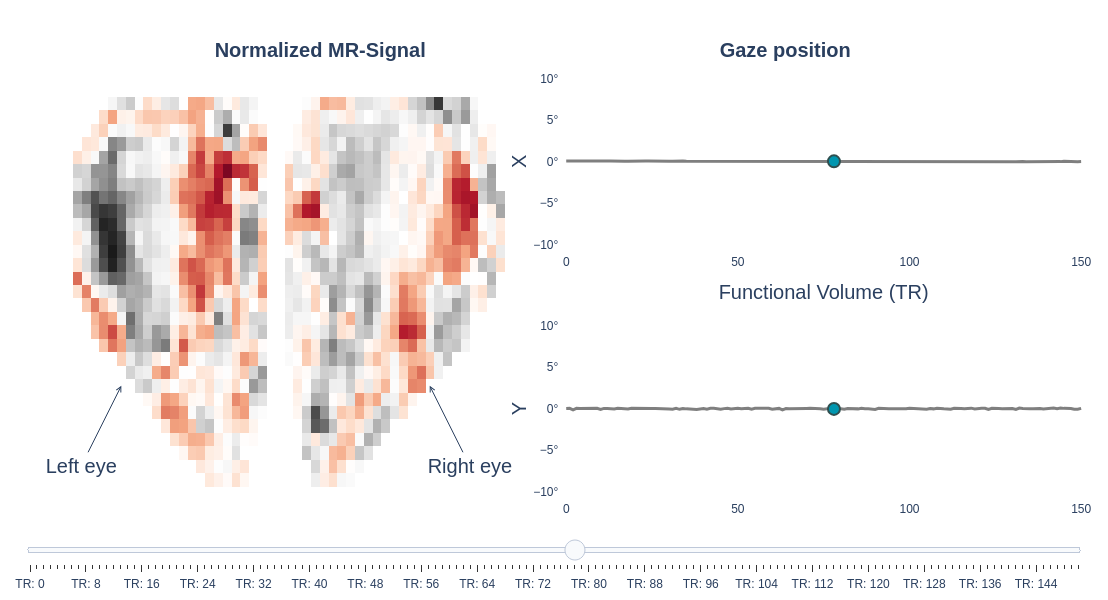

In [24]:
fig = analyse.visualise_input_data(X, y, bg_color="rgb(255,255,255)", ylim=[-11, 11])
fig.show()

In [3]:
# List all .npz files in folder
folder='/mnt/compneuro/deepmreye_finetuning/sleepybrain/nifti/'
npz_files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.npz')]

# Separate by type
left_files = [f for f in npz_files if f.endswith('_left.npz')]
right_files = [f for f in npz_files if f.endswith('_right.npz')]
both_files = [f for f in npz_files if not (f.endswith('_left.npz') or f.endswith('_right.npz'))]



In [4]:
opts = model_opts.get_opts()
print(opts)

{'kernel': 3, 'lr': 2e-05, 'filters': 32, 'multiplier': 2, 'depth': 4, 'dropout_rate': 0.1, 'num_dense': 2, 'num_fc': 1024, 'gaussian_noise': 0, 'activation': <function mish at 0x7f9400f40e50>, 'groups': 8, 'inner_timesteps': 10, 'loss_euclidean': 1, 'loss_confidence': 0.1, 'epochs': 25, 'steps_per_epoch': 1500, 'validation_steps': 1500, 'train_test_split': 0.6, 'batch_size': 8, 'mixed_batches': True, 'mc_dropout': False, 'rotation_x': 5, 'rotation_y': 5, 'rotation_z': 5, 'shift': 4, 'zoom': 0.15}


In [5]:
# Getting the list of all the available processed files -- Dataset 6 is excluded
all_files=[]
for root, dirs, files in os.walk('./processed_data/'):
    for name in files:
        all_files.append(os.path.join(root,name))
        print(os.path.join(root,name))

./processed_data/dataset1_guided_fixations/sub-NDARDE877RFH.npz
./processed_data/dataset1_guided_fixations/sub-NDARAA948VFH.npz
./processed_data/dataset1_guided_fixations/sub-NDARDL305BT8.npz
./processed_data/dataset1_guided_fixations/sub-NDARAC349YUC.npz
./processed_data/dataset1_guided_fixations/sub-NDARDH086ZKK.npz
./processed_data/dataset1_guided_fixations/sub-NDARAC350BZ0.npz
./processed_data/dataset1_guided_fixations/sub-NDARDL511UND.npz
./processed_data/dataset1_guided_fixations/sub-NDARAC495TJ2.npz
./processed_data/dataset1_guided_fixations/sub-NDARDN393BJH.npz
./processed_data/dataset1_guided_fixations/sub-NDARAD615WLJ.npz
./processed_data/dataset1_guided_fixations/sub-NDARDN489EXJ.npz
./processed_data/dataset1_guided_fixations/sub-NDARAE012DGA.npz
./processed_data/dataset1_guided_fixations/sub-NDAREF164ZUJ.npz
./processed_data/dataset1_guided_fixations/sub-NDARAE358VBE.npz
./processed_data/dataset1_guided_fixations/sub-NDAREF848YWD.npz
./processed_data/dataset1_guided_fixatio

In [42]:
# Create the test-train split with 0.8. All datasets were split with the same ratio

# Group by dataset (immediate parent folder name)
datasets = {}
for f in all_files:
    dataset_name = os.path.basename(os.path.dirname(f))
    datasets.setdefault(dataset_name, []).append(f)

# 80/20 split within each dataset
train_list_rs, test_list_rs = [], []
for dataset_name, files in datasets.items():
    files = sorted(files)                # deterministic ordering
    np.random.shuffle(files)             # randomize before splitting
    split_idx = int(0.8 * len(files))    # 80% train
    train_list_rs.extend(files[:split_idx])
    test_list_rs.extend(files[split_idx:])

print("Total train:", len(train_list_rs))
print("Total test:", len(test_list_rs))

Total train: 234
Total test: 60


In [ ]:

#with open("train_list_rs.txt", "w") as f:
#    for item in train_list_rs:
#        f.write(f"{item}\n")
        
#with open("test_list_rs.txt", "w") as f:
#    for item in test_list_rs:
#        f.write(f"{item}\n")

In [31]:
#np.savetxt('/mnt/compneuro/deepmreye_finetuning/sleepybrain/train_list.txt',train_list_rs,fmt="%s")
#np.savetxt('/mnt/compneuro/deepmreye_finetuning/sleepybrain/test_list.txt',test_list_rs,fmt="%s")

In [6]:
train_list_rs=np.loadtxt('/mnt/compneuro/deepmreye_finetuning/sleepybrain/train_list.txt',dtype=str)
test_list_rs=np.loadtxt('/mnt/compneuro/deepmreye_finetuning/sleepybrain/test_list.txt',dtype=str)

In [7]:
opts = model_opts.get_opts()
print(opts)

{'kernel': 3, 'lr': 2e-05, 'filters': 32, 'multiplier': 2, 'depth': 4, 'dropout_rate': 0.1, 'num_dense': 2, 'num_fc': 1024, 'gaussian_noise': 0, 'activation': <function mish at 0x7f9400f40e50>, 'groups': 8, 'inner_timesteps': 10, 'loss_euclidean': 1, 'loss_confidence': 0.1, 'epochs': 25, 'steps_per_epoch': 1500, 'validation_steps': 1500, 'train_test_split': 0.6, 'batch_size': 8, 'mixed_batches': True, 'mc_dropout': False, 'rotation_x': 5, 'rotation_y': 5, 'rotation_z': 5, 'shift': 4, 'zoom': 0.15}


In [46]:
# Create the generators fro the model trained on both eyes 
generators_both = create_holdout_generators(train_list=train_list_rs, test_list=test_list_rs, batch_size=opts['batch_size'], augment_list=((opts['rotation_x'], opts['rotation_y'], opts['rotation_z']), opts['shift'], opts['zoom']), mixed_batches=True)

Training set (./processed_data/dataset1_guided_fixations) contains 234 subjects: 
['sub-NDARYE379GGT', 'sub-NDAREC648WEL', 'sub-NDARRL426AD5', 'sub-NDAREK575JNM',
 'sub-NDAREY778CR9', 'sub-NDARRX800KW8', 'sub-NDARHX963YU1', 'sub-NDARTB203DU7',
 'sub-NDARNU770PM5', 'sub-NDARGV781AMW', 'sub-NDARXD710RLN', 'sub-NDARAP176AD1',
 'sub-NDARXE193CZ1', 'sub-NDAREK395BM3', 'sub-NDARAC350BZ0', 'sub-NDARXR346UT5',
 'sub-NDARWA433WYZ', 'sub-NDARCG159AAP', 'sub-NDARWV568MEU', 'sub-NDARGX443CEU',
 'sub-NDARFF644ZGD', 'sub-NDARJG298YVA', 'sub-NDARGH842VFY', 'sub-NDAREH852JE0',
 'sub-NDARCG438NML', 'sub-NDAREF893ZM8', 'sub-NDARBF805EHN', 'sub-NDARXL697DA6',
 'sub-NDARGB000CW8', 'sub-NDARGD425PTN', 'sub-NDARBH992ARB', 'sub-NDARGJ395FKP',
 'sub-NDARHD931FNA', 'sub-NDARAG115LZP', 'sub-NDARWJ498CZY', 'sub-NDARCR582GKJ',
 'sub-NDARRX897XV1', 'sub-NDARGE536BGD', 'sub-NDARED628HMQ', 'sub-NDARUY730ANT',
 'sub-NDARAC349YUC', 'sub-NDARKV807EMJ', 'sub-NDARFJ179MG0', 'sub-NDARCU736GZ1',
 'sub-NDARVN363NNQ', 'sub-N

In [50]:
# Train model
(model_both, model_inference_both) = train.train_model(dataset='both_eyes_RS-in-the-model', generators=generators_both, opts=opts, use_multiprocessing=False,
                                            return_untrained=False, verbose=1, save=True)

Input shape (8, 47, 29, 18, 1), Output shape (8, 10, 2)
Subjects in training set: 30, Subjects in test set: 30
Epoch 1/25


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f291e418400>>
Traceback (most recent call last):
  File "/home/CemalKoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 797, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

In [8]:
generators_both = data_generator.create_generators(test_list_rs,
                                              test_list_rs)
generators_both = (*generators_both, test_list_rs, test_list_rs
              )  
(model_both, model_inference_both) = train.train_model(dataset="prediction_on_both_eyes",
                                             generators=generators_both,
                                             opts=opts,
                                             return_untrained=True)
model_inference_both.load_weights('/mnt/compneuro/deepmreye_finetuning/modelinference_both_eyes_RS-in-the-model.h5')

Training set (./processed_data/dataset1_guided_fixations) contains 60 subjects: 
['sub-NDARDH086ZKK', 'sub-NDARYB392JWP', 'sub-NDARFM749LF3', 'sub-NDARGV948BFZ',
 'sub-NDARBE123PWH', 'sub-NDARGF543PM2', 'sub-NDARFU916UZY', 'sub-NDARCJ363KLE',
 'sub-NDARAE358VBE', 'sub-NDARCW611MK5', 'sub-NDARCL016NHB', 'sub-NDARTT272WT5',
 'sub-NDARDL511UND', 'sub-NDARGH074MU6', 'sub-NDARRZ927VC3', 'sub-NDARFU395UBW',
 'sub-NDARDY150ZP9', 'sub-NDARFE299MWU', 'sub-NDAREE675XRY', 'sub-NDARFM619GTV',
 'sub-NDARGN044FE4', 'sub-NDARDY776AKH', 'sub-NDARVP285RXV', 'sub-NDARGT551AFK',
 'sub-NDARWM656UWL', 'sub-NDARAA948VFH', 'sub-NDARAV610EY3', 'sub-NDARVC195NLH',
 'sub-NDARGK672URV', 'sub-NDARBT607PZL', 'sub-NDARER970AEF', 'sub-NDARJH492TVW',
 'sub-NDARAW179AYF', 'sub-NDARZM903TNL', 'AW_26_11_14', 'TK_17_12_14', 'S10_ET',
 'S15_ET', 'S04_ET', 'S08_ET', 'S05_ET', '40_OQ93', '29_YYOW', '12_SET4',
 '21_STHZ', '27_64E2', '13_ZEJI', '30_V776', 'S52', 'S28', 'S44', 'S24', 'S55',
 'S21', 'sub-9055', 'sub-9071', 'sub

2025-10-24 07:13:38.973515: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-10-24 07:13:39.027084: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-10-24 07:13:39.028476: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [9]:
#Evaluate the model 
(evaluation_both, scores_both) = train.evaluate_model(dataset='both_eyes', model=model_inference_both, generators=generators_both, save=True, model_description='', verbose=2, percentile_cut=80)

2025-10-24 07:13:43.061781: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907


1 / 60 - Model Performance for ./processed_data/dataset1_guided_fixations/sub-NDARDH086ZKK.npz
              Pearson             R^2-Score             Eucl. Error             
                    X     Y  Mean         X     Y  Mean        Mean Median   Std
Default         0.832 0.798 0.815     0.687 0.633 0.660       3.767  2.792 3.342
Default subTR   0.831 0.798 0.815     0.686 0.633 0.660       3.773  2.791 3.342
Refined         0.893 0.864 0.878     0.797 0.732 0.764       2.960  2.227 2.800
Refined subTR   0.887 0.864 0.875     0.786 0.732 0.759       2.996  2.247 2.861


2 / 60 - Model Performance for ./processed_data/dataset1_guided_fixations/sub-NDARYB392JWP.npz
              Pearson             R^2-Score             Eucl. Error             
                    X     Y  Mean         X     Y  Mean        Mean Median   Std
Default         0.953 0.942 0.947     0.908 0.880 0.894       1.855  1.223 2.089
Default subTR   0.953 0.941 0.947     0.907 0.879 0.893       1.862  1.222 2.09

/tmp/ipykernel_433792/1980667689.py:157: RuntimeWarning:

All-NaN slice encountered



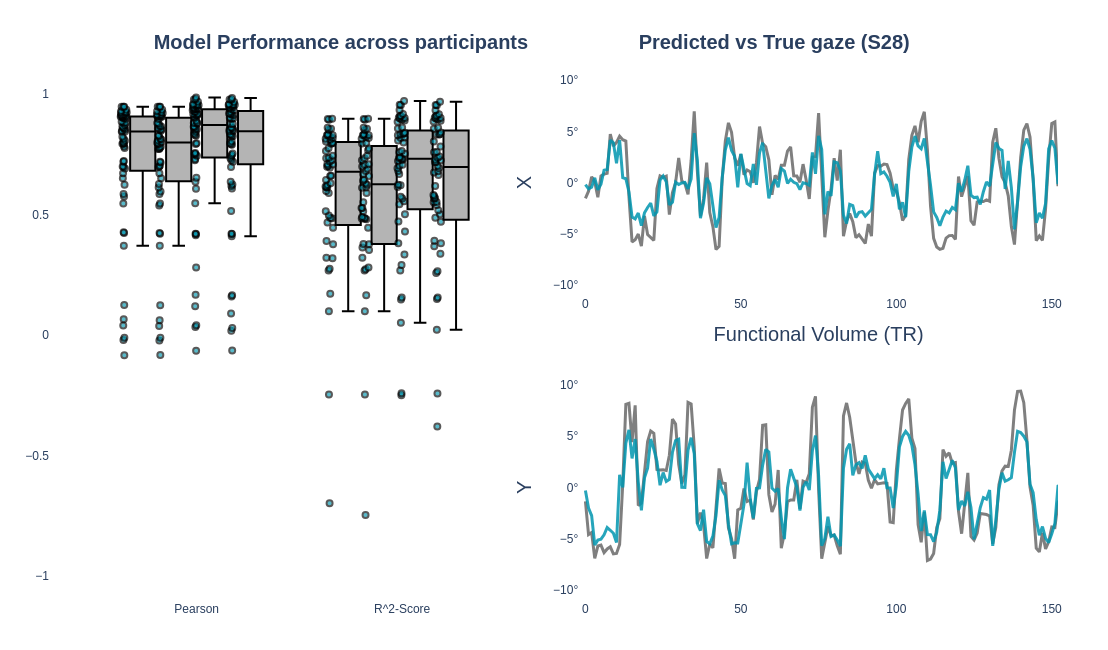

In [30]:
fig = visualise_predictions_static(evaluation_both, scores_both, color="rgb(0, 150, 175)", bg_color="rgb(255,255,255)",
                                   ylim=[-11, 11],subject_index=49)
fig.show()